# Лабораторная работа №1
## Освоение базового ML-пайплайна на табличных данных

**Выполнил:** Соколов Александр Сергеевич  
**Дисциплина:** Фреймворки машинного обучения  

**Задача 1 (регрессия):** предсказать CGPA по режиму занятий и сна  
**Задача 2 (классификация):** определить риск депрессии по образу жизни и уровню стресса

# 0. Импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

# 1. Загрузка и первичный осмотр данных

In [2]:
try:
    df = pd.read_csv('student_data.csv')
except FileNotFoundError:
    df = pd.read_csv('/kaggle/input/student-data/student_data.csv')

df_raw = df.copy()
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (1230, 14)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,CGPA_copy,Useless_Column,Random_Noise
0,1549,22.0,Female,Engineering,7.611554,5.464640,5.654419,3.812213,187.173912,4.512835,False,7.610886,A,0.314216
1,1705,19.0,Male,Medical,7.283270,5.958590,3.814198,3.761465,106.476345,4.723046,True,7.284289,A,0.576732
2,1245,23.0,Male,Science,6.582198,4.570177,2.784286,2.179695,175.724867,2.815291,False,6.582874,A,0.877673
3,1553,25.0,Female,Business,6.813965,7.725467,3.832814,8.040155,209.297064,2.000000,False,6.814186,A,0.964329
4,2165,22.0,Female,Medical,7.417254,6.928108,4.124715,0.310520,181.681121,4.285666,False,7.416699,A,0.056167


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          1230 non-null   int64  
 1   Age                 1230 non-null   float64
 2   Gender              1230 non-null   str    
 3   Department          1181 non-null   str    
 4   CGPA                1230 non-null   float64
 5   Sleep_Duration      1158 non-null   float64
 6   Study_Hours         1168 non-null   float64
 7   Social_Media_Hours  1181 non-null   float64
 8   Physical_Activity   1145 non-null   float64
 9   Stress_Level        1194 non-null   float64
 10  Depression          1230 non-null   bool   
 11  CGPA_copy           1230 non-null   float64
 12  Useless_Column      1230 non-null   str    
 13  Random_Noise        1230 non-null   float64
dtypes: bool(1), float64(9), int64(1), str(3)
memory usage: 126.3 KB


In [4]:
df.describe(include='all')

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,CGPA_copy,Useless_Column,Random_Noise
count,1230.000000,1230.000000,1230,1181,1230.000000,1158.000000,1168.000000,1181.000000,1145.000000,1194.000000,1230,1230.000000,1230,1230.000000
unique,NaN,NaN,5,5,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,1,NaN
top,NaN,NaN,Male,Engineering,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,A,NaN
freq,NaN,NaN,587,313,NaN,NaN,NaN,NaN,NaN,NaN,1030,NaN,1230,NaN
mean,1599.424390,22.534959,NaN,NaN,7.617630,6.578179,4.998388,3.080094,154.689798,5.444229,NaN,7.617621,NaN,0.516454
std,347.889174,9.908286,NaN,NaN,0.832599,1.639997,1.749803,2.161164,91.708716,1.851647,NaN,0.832663,NaN,0.287153
min,1001.000000,-5.000000,NaN,NaN,-2.000000,-1.000000,-1.000000,-2.513163,-113.346875,2.000000,NaN,-2.000583,NaN,0.000690
25%,1297.250000,20.000000,NaN,NaN,7.115507,5.719045,3.950451,1.832955,112.029393,4.123088,NaN,7.114319,NaN,0.274157
50%,1599.500000,22.000000,NaN,NaN,7.629676,6.515489,4.954778,2.914180,152.542874,5.381318,NaN,7.629176,NaN,0.532186
75%,1899.750000,24.000000,NaN,NaN,8.115745,7.399433,5.908861,4.324901,192.784157,6.713005,NaN,8.115713,NaN,0.772983


In [5]:
print('Пропущенные значения:')
print(df.isnull().sum())
print('\nДубликатов:', df.duplicated().sum())
print('\nУникальные Gender:', df.Gender.unique())
if 'Department' in df.columns:
    print('Уникальные Department:', df['Department'].dropna().unique())


Пропущенные значения:
Student_ID             0
Age                    0
Gender                 0
Department            49
CGPA                   0
Sleep_Duration        72
Study_Hours           62
Social_Media_Hours    49
Physical_Activity     85
Stress_Level          36
Depression             0
CGPA_copy              0
Useless_Column         0
Random_Noise           0
dtype: int64

Дубликатов: 0

Уникальные Gender: <StringArray>
['Female', 'Male', 'male', 'FEMALE', 'M']
Length: 5, dtype: str
Уникальные Department: <StringArray>
['Engineering', 'Medical', 'Science', 'Business', 'Arts']
Length: 5, dtype: str


# 2. Разведочный анализ данных (EDA)

Исследуем распределения, ищем выбросы, анализируем категориальные признаки и изучаем связи между переменными.

## 2.1 Пропущенные значения

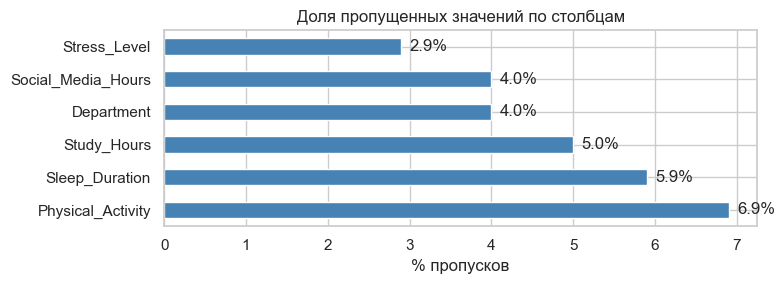

In [6]:
miss = (df.isnull().sum() / len(df) * 100).round(1)
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
miss.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% пропусков')
ax.set_title('Доля пропущенных значений по столбцам')
for i, v in enumerate(miss):
    ax.text(v + 0.1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

## 2.2 Выбросы и логические ошибки

In [7]:
print(f'Age вне [15, 45]:               {((df.Age < 15) | (df.Age > 45)).sum()} строк')
print(f'Sleep_Duration вне [0, 24]:     {((df.Sleep_Duration < 0) | (df.Sleep_Duration > 24)).sum()} строк')
print(f'CGPA вне [0, 10]:               {((df.CGPA < 0) | (df.CGPA > 10)).sum()} строк')
print(f'Study_Hours вне [0, 24]:        {((df.Study_Hours < 0) | (df.Study_Hours > 24)).sum()} строк')
print(f'Physical_Activity вне [0,1000]: {((df.Physical_Activity < 0) | (df.Physical_Activity > 1000)).sum()} строк')
print(f'Social_Media_Hours вне [0,24]:  {((df.Social_Media_Hours < 0) | (df.Social_Media_Hours > 24)).sum()} строк')
print(f'Stress_Level вне [1, 10]:       {((df.Stress_Level < 1) | (df.Stress_Level > 10)).sum()} строк')

Age вне [15, 45]:               6 строк
Sleep_Duration вне [0, 24]:     4 строк
CGPA вне [0, 10]:               4 строк
Study_Hours вне [0, 24]:        6 строк
Physical_Activity вне [0,1000]: 16 строк
Social_Media_Hours вне [0,24]:  54 строк
Stress_Level вне [1, 10]:       0 строк


## 2.3 Распределения числовых признаков

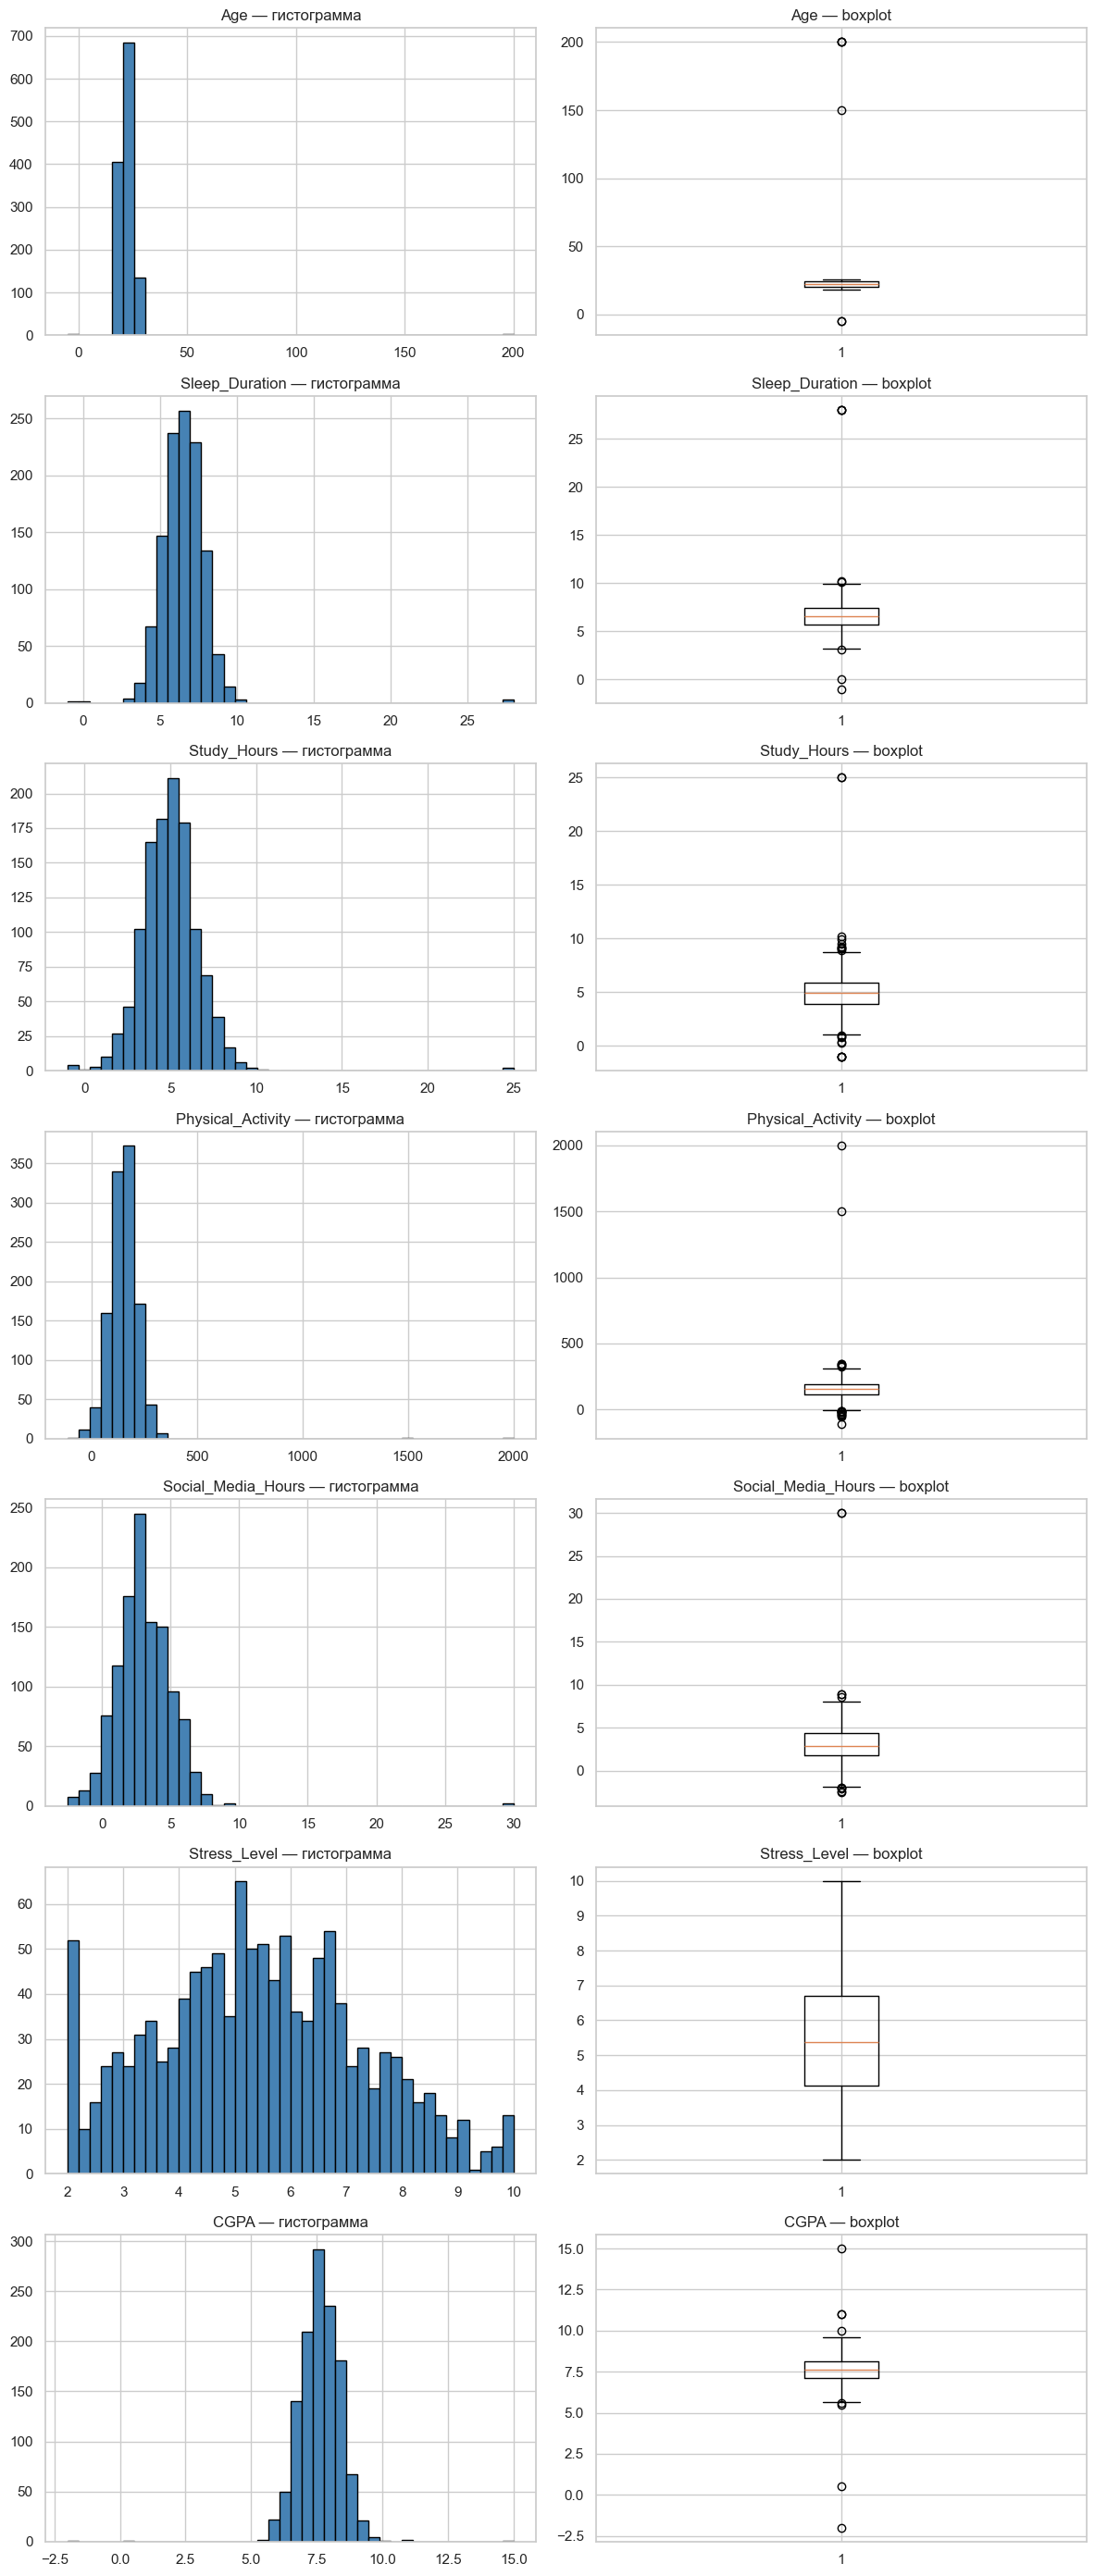

In [8]:
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Stress_Level', 'CGPA']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    axes[i, 0].hist(df[col].dropna(), bins=40, edgecolor='black', color='steelblue')
    axes[i, 0].set_title(f'{col} — гистограмма')
    axes[i, 1].boxplot(df[col].dropna())
    axes[i, 1].set_title(f'{col} — boxplot')
plt.tight_layout()
plt.show()

## 2.4 Категориальные признаки

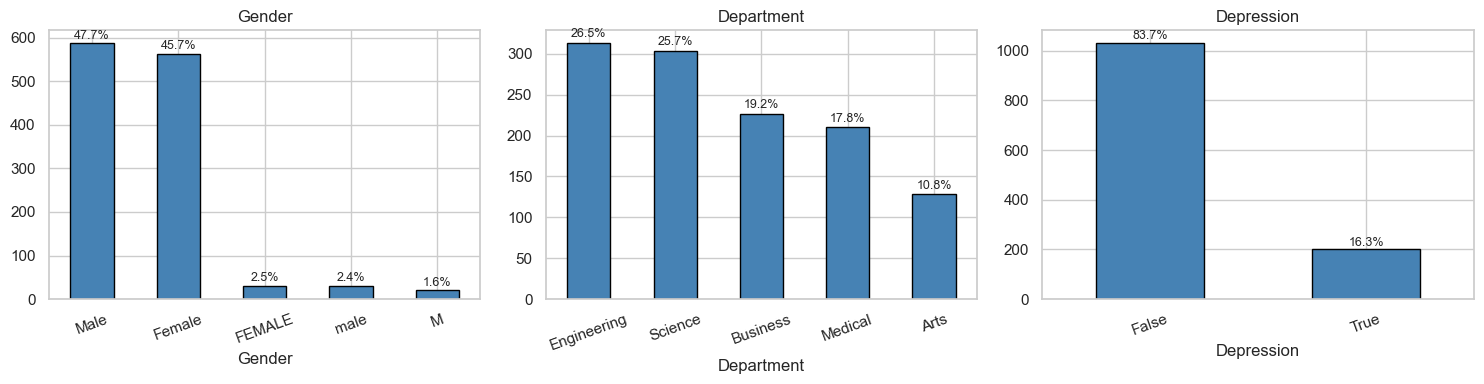

Доля классов Depression:
Depression
False    0.837
True     0.163
Name: proportion, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Gender', 'Department', 'Depression']):
    counts = df[col].value_counts()
    counts.plot.bar(ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
    total = counts.sum()
    for p, v in zip(ax.patches, counts):
        ax.text(p.get_x() + p.get_width() / 2,
                p.get_height() + total * 0.003,
                f'{v / total:.1%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Доля классов Depression:')
print(df['Depression'].value_counts(normalize=True).round(3))

## 2.5 Корреляция (Pearson и Spearman)

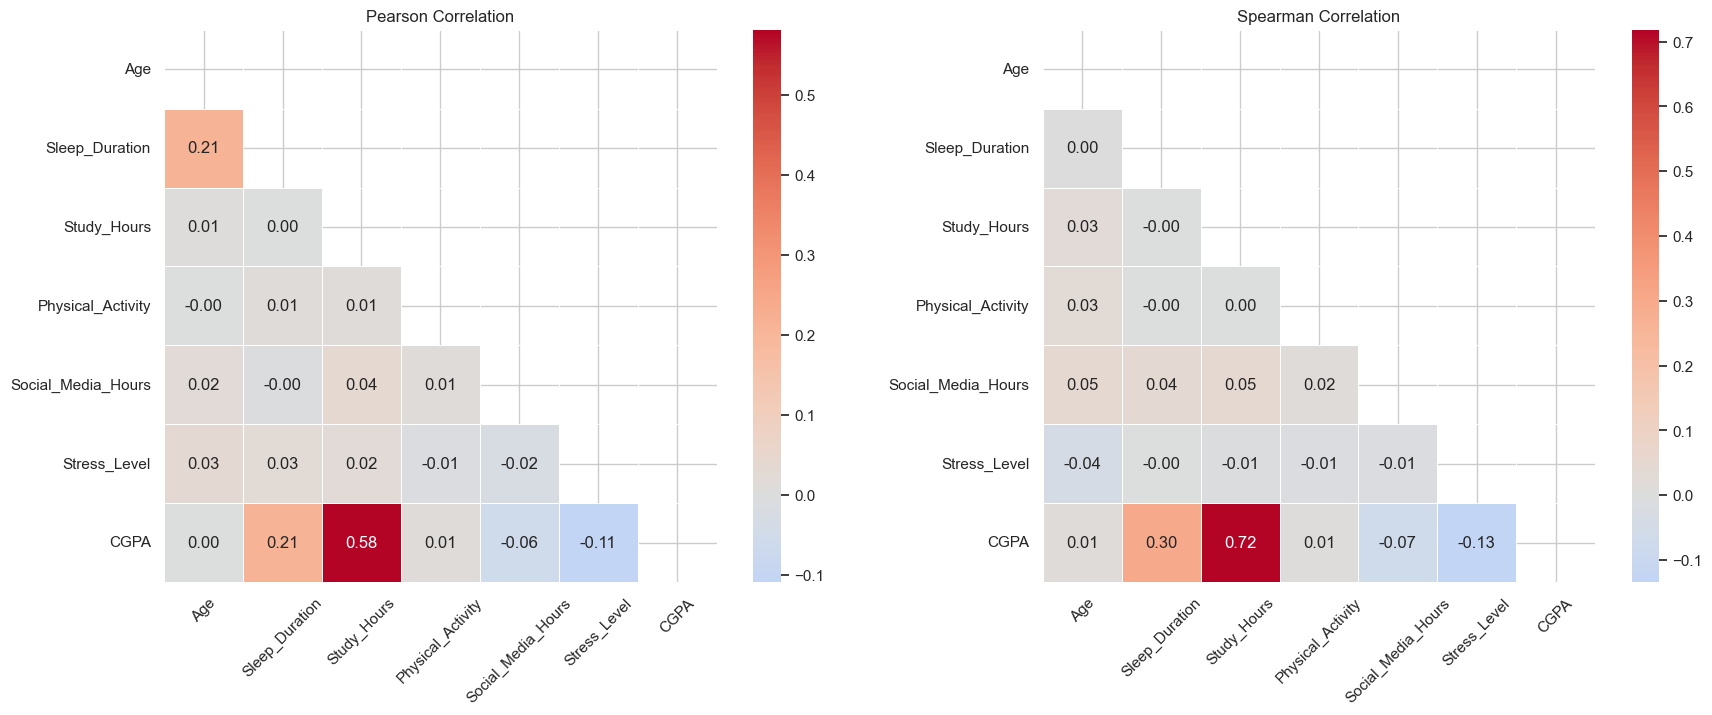

In [10]:
pearson_corr  = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr,  mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson Correlation')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Spearman Correlation')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2.6 Связь признаков с целевыми переменными

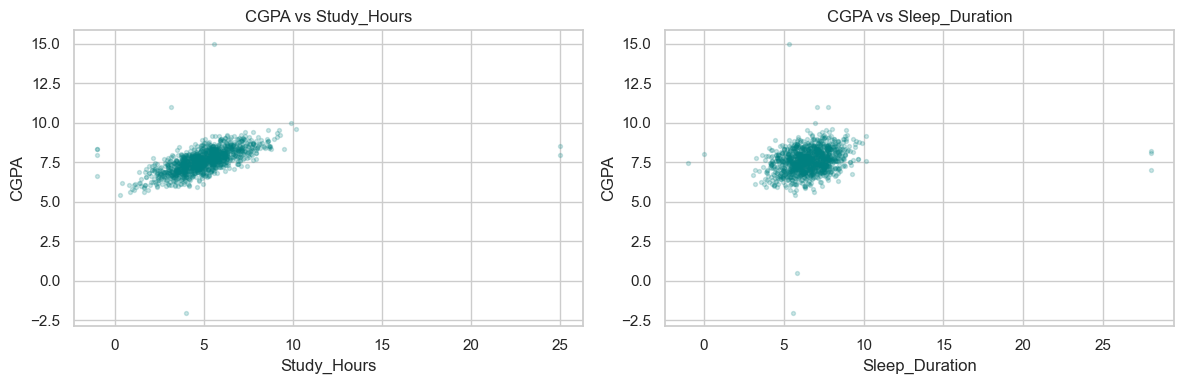

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Study_Hours', 'Sleep_Duration']):
    ax.scatter(df[col], df['CGPA'], alpha=0.2, s=8, color='teal')
    ax.set_xlabel(col)
    ax.set_ylabel('CGPA')
    ax.set_title(f'CGPA vs {col}')
plt.tight_layout()
plt.show()

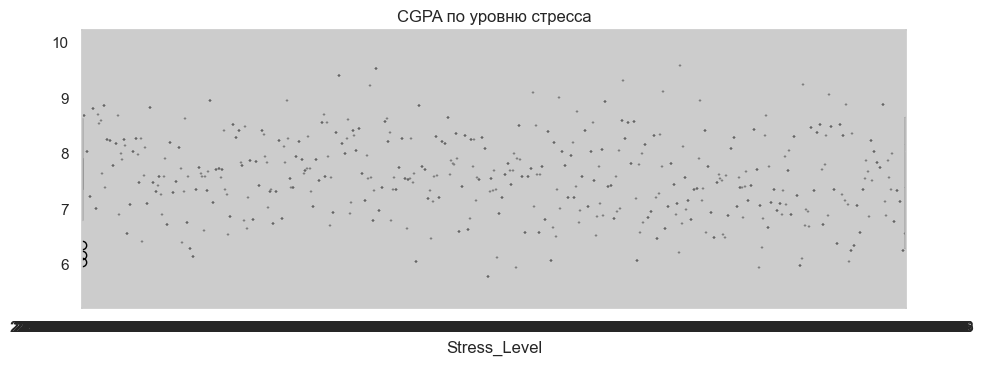

In [12]:
valid = df[(df.CGPA >= 4) & (df.CGPA <= 10)]
fig, ax = plt.subplots(figsize=(10, 4))
valid.boxplot('CGPA', by='Stress_Level', ax=ax)
ax.set_title('CGPA по уровню стресса')
ax.set_xlabel('Stress_Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

# 3. Предобработка

Выявленные проблемы и принятые решения:

| Проблема | Решение | Обоснование |
|---|---|---|
| Дубликаты строк | удаление | повторяющиеся наблюдения искажают обучение |
| `Student_ID` — идентификатор | удаление | не несёт предсказательной силы |
| `CGPA_copy` — копия `CGPA` | удаление | прямая утечка данных |
| `Useless_Column`, `Random_Noise` | удаление | константа и шум — не информативны |
| Нереалистичные значения | замена на NaN | выбросы за пределами физически возможного диапазона |
| Несогласованный Gender | нормализация | 5 форматов → 2 категории |
| Пропуски в числовых столбцах | медиана | устойчива к выбросам |
| Пропуски в категориальных | мода | базовое и интерпретируемое решение |
| `Depression` — boolean | int(0/1) | требование sklearn |
| `Gender` — бинарный | int(0/1) | Female=1, Male=0 |
| `Department` — номинальный | One-Hot (drop_first) | нет порядка между факультетами; ordinal навязывал бы линейную зависимость Arts<...<Engineering |

## 3.1 Дубликаты и мусорные столбцы

In [13]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
print(f'Удалено дубликатов: {before - len(df)}')

df = df.drop(columns=['Student_ID', 'CGPA_copy', 'Useless_Column', 'Random_Noise'])
print(f'Столбцов осталось: {df.shape[1]}')

Удалено дубликатов: 0
Столбцов осталось: 10


## 3.2 Логические ошибки → NaN

In [14]:
df.loc[(df.Age < 15) | (df.Age > 45), 'Age'] = np.nan
df.loc[(df.Sleep_Duration < 0) | (df.Sleep_Duration > 24), 'Sleep_Duration'] = np.nan
df.loc[(df.CGPA < 0) | (df.CGPA > 10), 'CGPA'] = np.nan
df.loc[(df.Study_Hours < 0) | (df.Study_Hours > 24), 'Study_Hours'] = np.nan
df.loc[(df.Physical_Activity < 0) | (df.Physical_Activity > 1000), 'Physical_Activity'] = np.nan
df.loc[(df.Social_Media_Hours < 0) | (df.Social_Media_Hours > 24), 'Social_Media_Hours'] = np.nan
df.loc[(df.Stress_Level < 1) | (df.Stress_Level > 10), 'Stress_Level'] = np.nan

print('Пропусков после замены выбросов:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Пропусков после замены выбросов:
Age                     6
Department             49
CGPA                    4
Sleep_Duration         76
Study_Hours            68
Social_Media_Hours    103
Physical_Activity     101
Stress_Level           36
dtype: int64


## 3.3 Нормализация Gender

In [15]:
def normalize_gender(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ('male', 'm'):
        return 'Male'
    if v in ('female', 'f'):
        return 'Female'
    return np.nan

df['Gender'] = df['Gender'].apply(normalize_gender)
print(df['Gender'].value_counts())

Gender
Male      637
Female    593
Name: count, dtype: int64


## 3.4 Заполнение пропусков

In [16]:
num_fill = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Stress_Level', 'CGPA']
cat_fill = ['Gender', 'Department']

for col in num_fill:
    df[col] = df[col].fillna(df[col].median())
for col in cat_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Пропусков осталось: {df.isnull().sum().sum()}')

Пропусков осталось: 0


## 3.5 Кодирование категориальных признаков

In [17]:
df['Gender']     = (df['Gender'] == 'Female').astype(int)
df['Depression'] = df['Depression'].astype(int)

df = pd.get_dummies(df, columns=['Department'], drop_first=True, dtype=int)
# Базовая категория — Arts (отброшена); остаются: Business, Engineering, Medical, Science

print(df.dtypes)

Age                       float64
Gender                      int64
CGPA                      float64
Sleep_Duration            float64
Study_Hours               float64
Social_Media_Hours        float64
Physical_Activity         float64
Stress_Level              float64
Depression                  int64
Department_Business         int64
Department_Engineering      int64
Department_Medical          int64
Department_Science          int64
dtype: object


## 3.6 Распределения после очистки

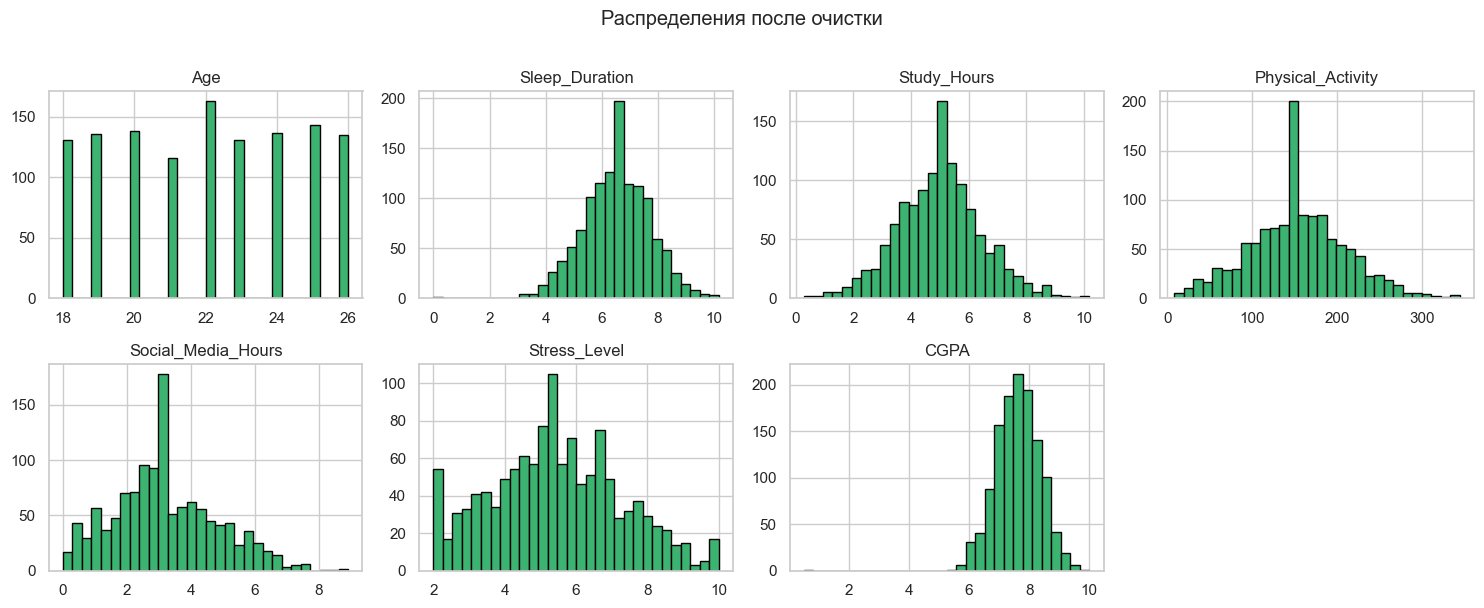

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flatten(), num_fill):
    ax.hist(df[col], bins=30, edgecolor='black', color='mediumseagreen')
    ax.set_title(col)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Распределения после очистки', y=1.01)
plt.tight_layout()
plt.show()

# 4. Feature Engineering и отбор признаков

Создаём три новых признака:
- **Study_Sleep_Ratio** — отношение часов учёбы к часам сна (нагрузка vs отдых)
- **Wellness_Score** — комбинация сна и физической активности (общее состояние)
- **Load_Index** — суммарная нагрузка: стресс + соцсети − учёба

Отбор релевантных признаков проводим через Mutual Information — мера нелинейной зависимости.

In [19]:
df['Study_Sleep_Ratio'] = df['Study_Hours'] / (df['Sleep_Duration'] + 0.1)
df['Wellness_Score']    = df['Sleep_Duration'] * 0.4 + (df['Physical_Activity'] / 100) * 0.6
df['Load_Index']        = df['Stress_Level'] + df['Social_Media_Hours'] * 0.3 - df['Study_Hours'] * 0.1

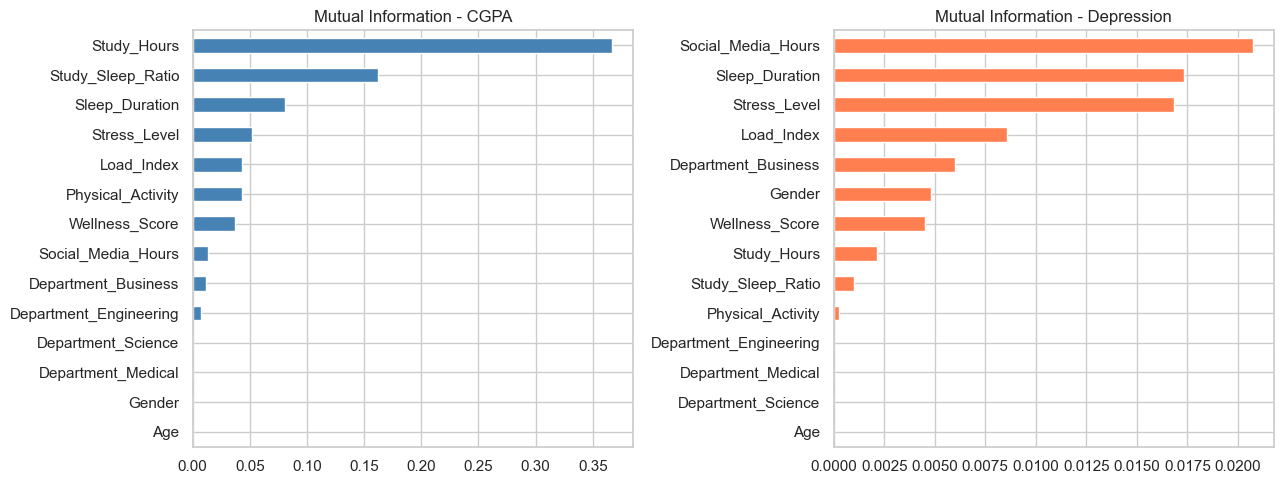

Топ-5 для CGPA:
Load_Index           0.043532
Stress_Level         0.051828
Sleep_Duration       0.080347
Study_Sleep_Ratio    0.161784
Study_Hours          0.366845
Топ-5 для Depression:
Department_Business    0.006023
Load_Index             0.008557
Stress_Level           0.016860
Sleep_Duration         0.017358
Social_Media_Hours     0.020751


In [20]:
DEPT_COLS = [col for col in df.columns if col.startswith("Department_")]

all_features = [
    "Age", "Gender", "Sleep_Duration", "Study_Hours",
    "Physical_Activity", "Social_Media_Hours", "Stress_Level",
    "Study_Sleep_Ratio", "Wellness_Score", "Load_Index",
] + DEPT_COLS

mi_reg = pd.Series(
    mutual_info_regression(df[all_features], df["CGPA"], random_state=SEED),
    index=all_features
).sort_values()

mi_clf = pd.Series(
    mutual_info_classif(df[all_features], df["Depression"], random_state=SEED),
    index=all_features
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mi_reg.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Mutual Information - CGPA")
mi_clf.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Mutual Information - Depression")
plt.tight_layout()
plt.show()

print("Топ-5 для CGPA:")
print(mi_reg.tail(5).to_string())
print("Топ-5 для Depression:")
print(mi_clf.tail(5).to_string())


In [21]:
REG_FEATURES = ["Sleep_Duration", "Study_Hours", "Study_Sleep_Ratio"]

CLF_FEATURES = [
    "Stress_Level", "Sleep_Duration", "Social_Media_Hours",
    "Physical_Activity", "Gender",
    "Load_Index", "Wellness_Score",
] + DEPT_COLS

print("Признаки регрессии:", REG_FEATURES)
print("Признаки классификации:", CLF_FEATURES)

Признаки регрессии: ['Sleep_Duration', 'Study_Hours', 'Study_Sleep_Ratio']
Признаки классификации: ['Stress_Level', 'Sleep_Duration', 'Social_Media_Hours', 'Physical_Activity', 'Gender', 'Load_Index', 'Wellness_Score', 'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science']


# 5. Разделение данных (60 / 20 / 20)

StandardScaler обучается только на тренировочной части — утечки данных нет. Scalers сохраняются для последующего предсказания на новых данных.

In [22]:
def split_dataset(X, y, seed=SEED):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=seed)
    return X_train, X_val, X_te, y_train, y_val, y_te

X_reg_tr, X_reg_va, X_reg_te, y_reg_train, y_reg_val, y_reg_test = split_dataset(
    df[REG_FEATURES].values, df['CGPA'].values
)
scaler_reg = StandardScaler()
X_reg_train = scaler_reg.fit_transform(X_reg_tr)
X_reg_val   = scaler_reg.transform(X_reg_va)
X_reg_test  = scaler_reg.transform(X_reg_te)

X_clf_tr, X_clf_va, X_clf_te, y_clf_train, y_clf_val, y_clf_test = split_dataset(
    df[CLF_FEATURES].values, df['Depression'].values
)
scaler_clf = StandardScaler()
X_clf_train = scaler_clf.fit_transform(X_clf_tr)
X_clf_val   = scaler_clf.transform(X_clf_va)
X_clf_test  = scaler_clf.transform(X_clf_te)

print('Регрессия  — train / val / test:',
      X_reg_train.shape[0], X_reg_val.shape[0], X_reg_test.shape[0])
print('Классификация — train / val / test:',
      X_clf_train.shape[0], X_clf_val.shape[0], X_clf_test.shape[0])

Регрессия  — train / val / test: 738 246 246
Классификация — train / val / test: 738 246 246


# 6. Линейная регрессия — прогноз CGPA

## 6.1 Обучение и метрики

In [23]:
def regression_report(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}')
    return rmse, mae, r2

lin = LinearRegression()
lin.fit(X_reg_train, y_reg_train)

regression_report(y_reg_train, lin.predict(X_reg_train), 'Train')
regression_report(y_reg_val,   lin.predict(X_reg_val),   'Val  ')
regression_report(y_reg_test,  lin.predict(X_reg_test),  'Test ')

print('\nКоэффициенты:')
coef_df = pd.DataFrame({'Feature': REG_FEATURES, 'Coefficient': lin.coef_}).sort_values('Coefficient')
print(coef_df.to_string(index=False))

Train: RMSE=0.4470, MAE=0.3595, R²=0.6036
Val  : RMSE=0.6052, MAE=0.3512, R²=0.5125
Test : RMSE=0.4694, MAE=0.3790, R²=0.5622

Коэффициенты:
          Feature  Coefficient
Study_Sleep_Ratio     0.061308
   Sleep_Duration     0.229674
      Study_Hours     0.487516


## 6.2 Визуализации

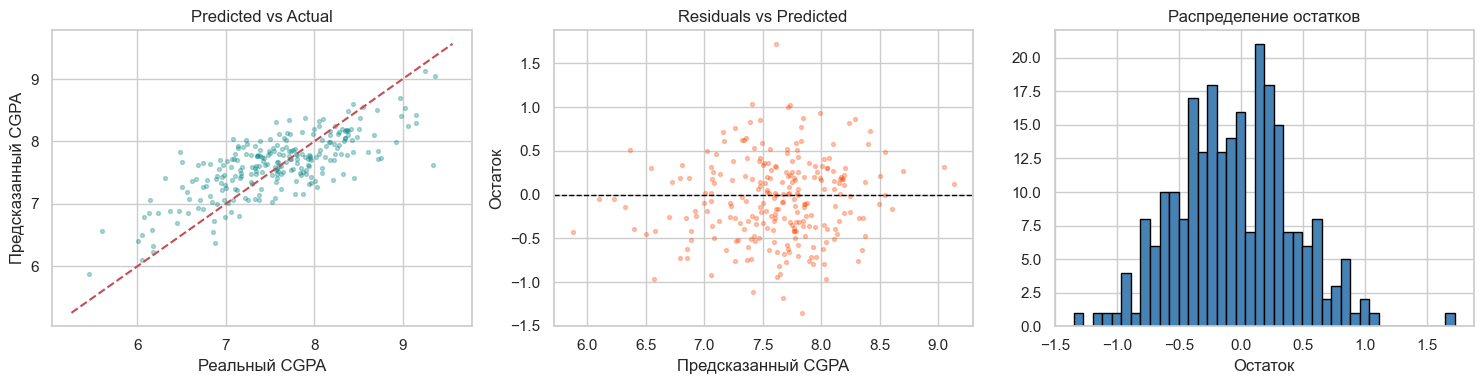

In [24]:
y_pred_reg = lin.predict(X_reg_test)
residuals  = y_reg_test - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.3, s=8, color='teal')
lim = [min(y_reg_test.min(), y_pred_reg.min()) - 0.2,
       max(y_reg_test.max(), y_pred_reg.max()) + 0.2]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Реальный CGPA')
axes[0].set_ylabel('Предсказанный CGPA')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(y_pred_reg, residuals, alpha=0.3, s=8, color='orangered')
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Предсказанный CGPA')
axes[1].set_ylabel('Остаток')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=40, edgecolor='black', color='steelblue')
axes[2].set_xlabel('Остаток')
axes[2].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

# 7. Логистическая регрессия — классификация Depression

## 7.1 Кастомная реализация логистической регрессии

Реализуем логистическую регрессию с нуля на NumPy — градиентный спуск с взвешенным лоссом для компенсации дисбаланса классов.

In [25]:
class LogReg:
    def __init__(self, lr=0.01, n_iter=100, seed=42):
        self.lr     = lr
        self.n_iter = n_iter
        self.seed   = seed
        self.w      = None
        self.b      = 0.0
        self.loss_hist      = []
        self.train_acc_hist = []
        self.val_acc_hist   = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y, X_val=None, y_val=None):
        np.random.seed(self.seed)
        n, m = X.shape
        self.w = np.zeros(m)
        self.b = 0.0
        self.loss_hist      = []
        self.train_acc_hist = []
        self.val_acc_hist   = []

        n1 = int(y.sum())
        n0 = n - n1
        sw = np.where(y == 1, n / (2 * n1), n / (2 * n0))

        for _ in range(self.n_iter):
            p   = self._sigmoid(X @ self.w + self.b)
            eps = 1e-9
            loss = -np.mean(sw * (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
            self.loss_hist.append(loss)

            err    = sw * (p - y)
            self.w -= self.lr * (X.T @ err) / n
            self.b -= self.lr * err.mean()

            if X_val is not None:
                self.train_acc_hist.append(accuracy_score(y, self.predict(X)))
                self.val_acc_hist.append(accuracy_score(y_val, self.predict(X_val)))

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)

## 7.2 Эксперимент: learning rate × число эпох

Перебираем 4 значения learning rate и 5 значений числа итераций. Ищем комбинацию с наилучшим val F1.

In [26]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs_list    = [10, 50, 100, 200, 500]
results = []

for lr in learning_rates:
    for epochs in epochs_list:
        m = LogReg(lr=lr, n_iter=epochs, seed=SEED)
        m.fit(X_clf_train, y_clf_train)
        y_vp = m.predict(X_clf_val)
        results.append({
            'lr': lr, 'epochs': epochs,
            'train_acc': accuracy_score(y_clf_train, m.predict(X_clf_train)),
            'val_acc':   accuracy_score(y_clf_val,   y_vp),
            'val_f1':    f1_score(y_clf_val, y_vp, zero_division=0)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

    lr  epochs  train_acc  val_acc   val_f1
0.1000      10   0.573171 0.548780 0.292994
0.1000      50   0.588076 0.569106 0.311688
0.1000     100   0.604336 0.573171 0.304636
0.1000     200   0.609756 0.585366 0.310811
0.1000     500   0.608401 0.585366 0.310811
0.0100      10   0.571816 0.532520 0.276730
0.0100      50   0.571816 0.548780 0.292994
0.0100     100   0.573171 0.548780 0.292994
0.0100     200   0.579946 0.560976 0.307692
0.0100     500   0.588076 0.569106 0.311688
0.0010      10   0.569106 0.532520 0.276730
0.0010      50   0.570461 0.528455 0.275000
0.0010     100   0.571816 0.532520 0.276730
0.0010     200   0.571816 0.540650 0.289308
0.0010     500   0.571816 0.548780 0.292994
0.0001      10   0.569106 0.532520 0.276730
0.0001      50   0.569106 0.532520 0.276730
0.0001     100   0.569106 0.532520 0.276730
0.0001     200   0.570461 0.532520 0.276730
0.0001     500   0.570461 0.528455 0.275000


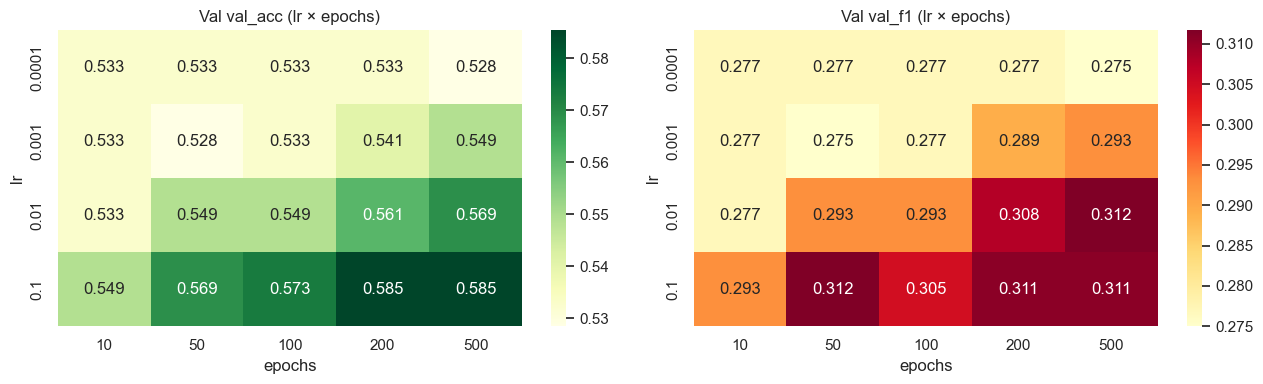

Лучшие: lr=0.1, epochs=50, val_acc=0.569, val_f1=0.312


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, cmap in zip(axes, ['val_acc', 'val_f1'], ['YlGn', 'YlOrRd']):
    pivot = results_df.pivot(index='lr', columns='epochs', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax)
    ax.set_title(f'Val {metric} (lr × epochs)')
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f'Лучшие: lr={best.lr}, epochs={int(best.epochs)}, '
      f'val_acc={best.val_acc:.3f}, val_f1={best.val_f1:.3f}')

## 7.3 Доказательство отсутствия переобучения

Обучаем лучшую модель с отслеживанием train/val accuracy и loss на каждой эпохе.

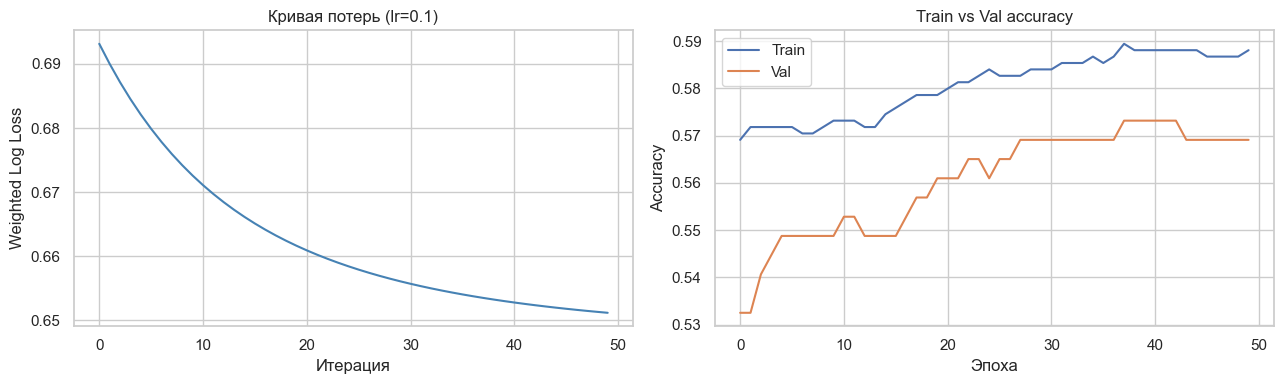

Разрыв train–val: макс=0.0393, последняя эпоха=0.0190


In [28]:
best_lr     = float(best.lr)
best_epochs = int(best.epochs)

best_model = LogReg(lr=best_lr, n_iter=best_epochs, seed=SEED)
best_model.fit(X_clf_train, y_clf_train, X_val=X_clf_val, y_val=y_clf_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(best_model.loss_hist, color='steelblue')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Weighted Log Loss')
axes[0].set_title(f'Кривая потерь (lr={best_lr})')

axes[1].plot(best_model.train_acc_hist, label='Train')
axes[1].plot(best_model.val_acc_hist,   label='Val')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Val accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

gap = np.array(best_model.train_acc_hist) - np.array(best_model.val_acc_hist)
print(f'Разрыв train–val: макс={gap.max():.4f}, последняя эпоха={gap[-1]:.4f}')

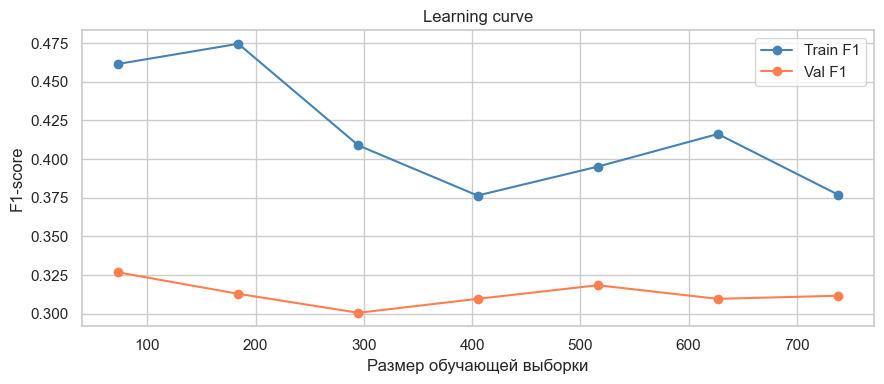

Разрыв train/val F1 на полной выборке: 0.0654
Есть признаки переобучения


In [29]:
fracs = np.linspace(0.1, 1.0, 7)
lc_train_f1, lc_val_f1 = [], []

for frac in fracs:
    n = max(int(len(X_clf_train) * frac), 10)
    lc_model = LogReg(lr=best_lr, n_iter=best_epochs, seed=SEED)
    lc_model.fit(X_clf_train[:n], y_clf_train[:n])
    lc_train_f1.append(f1_score(y_clf_train[:n], lc_model.predict(X_clf_train[:n]), zero_division=0))
    lc_val_f1.append(f1_score(y_clf_val, lc_model.predict(X_clf_val), zero_division=0))

sizes = (fracs * len(X_clf_train)).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, lc_train_f1, 'o-', color='steelblue', label='Train F1')
ax.plot(sizes, lc_val_f1,   'o-', color='coral',     label='Val F1')
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('F1-score')
ax.set_title('Learning curve')
ax.legend()
plt.tight_layout()
plt.show()

final_gap = abs(lc_train_f1[-1] - lc_val_f1[-1])
print(f'Разрыв train/val F1 на полной выборке: {final_gap:.4f}')
print('Переобучение отсутствует' if final_gap < 0.05 else 'Есть признаки переобучения')

## 7.4 Финальная модель и метрики

Финальная оценка на тестовой выборке — sklearn LogisticRegression как аналитический базис сравнения.

In [30]:
def clf_report(y_true, y_pred, y_proba, label):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    print(f'{label}: acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}')
    return acc, prec, rec, f1, auc

clf_final = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
clf_final.fit(X_clf_train, y_clf_train)

y_pred  = clf_final.predict(X_clf_test)
y_proba = clf_final.predict_proba(X_clf_test)[:, 1]

clf_report(y_clf_train, clf_final.predict(X_clf_train),
           clf_final.predict_proba(X_clf_train)[:, 1], 'Train')
clf_report(y_clf_val,   clf_final.predict(X_clf_val),
           clf_final.predict_proba(X_clf_val)[:, 1],   'Val  ')
clf_report(y_clf_test,  y_pred, y_proba, 'Test ')

Train: acc=0.608  prec=0.270  rec=0.679  f1=0.386  auc=0.675
Val  : acc=0.573  prec=0.200  rec=0.639  f1=0.305  auc=0.628
Test : acc=0.581  prec=0.139  rec=0.467  f1=0.214  auc=0.605


(0.5813008130081301,
 0.13861386138613863,
 0.4666666666666667,
 0.21374045801526717,
 0.6054012345679012)

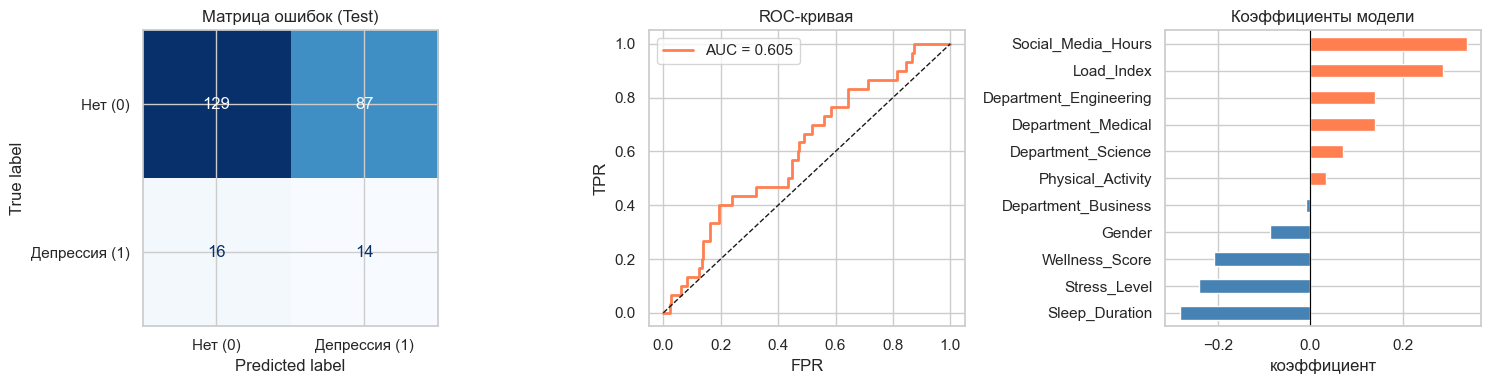

In [31]:
auc = roc_auc_score(y_clf_test, y_proba)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_clf_test, y_pred),
    display_labels=['Нет (0)', 'Депрессия (1)']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Матрица ошибок (Test)')

fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='coral', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC-кривая')
axes[1].legend()

coef = pd.Series(clf_final.coef_[0], index=CLF_FEATURES).sort_values()
coef.plot.barh(ax=axes[2], color=['coral' if v > 0 else 'steelblue' for v in coef])
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Коэффициенты модели')
axes[2].set_xlabel('коэффициент')

plt.tight_layout()
plt.show()

# 8. Итоговая оценка качества моделей

In [32]:
print('=' * 58)
print('Линейная регрессия (CGPA):')
regression_report(y_reg_train, lin.predict(X_reg_train), '  Train')
regression_report(y_reg_val,   lin.predict(X_reg_val),   '  Val  ')
regression_report(y_reg_test,  lin.predict(X_reg_test),  '  Test ')
print('=' * 58)
print('Логистическая регрессия (Depression):')
clf_report(y_clf_train, clf_final.predict(X_clf_train),
           clf_final.predict_proba(X_clf_train)[:, 1], '  Train')
clf_report(y_clf_val,   clf_final.predict(X_clf_val),
           clf_final.predict_proba(X_clf_val)[:, 1],   '  Val  ')
clf_report(y_clf_test,  y_pred, y_proba, '  Test ')
print('=' * 58)

Линейная регрессия (CGPA):
  Train: RMSE=0.4470, MAE=0.3595, R²=0.6036
  Val  : RMSE=0.6052, MAE=0.3512, R²=0.5125
  Test : RMSE=0.4694, MAE=0.3790, R²=0.5622
Логистическая регрессия (Depression):
  Train: acc=0.608  prec=0.270  rec=0.679  f1=0.386  auc=0.675
  Val  : acc=0.573  prec=0.200  rec=0.639  f1=0.305  auc=0.628
  Test : acc=0.581  prec=0.139  rec=0.467  f1=0.214  auc=0.605


# 9. Предсказание на своих данных

In [33]:
my_sleep    = 7.0
my_study    = 6.0
my_stress   = 5
my_social   = 3.0
my_physical = 120
my_gender   = 1    # Female=1, Male=0
my_dept     = 'Science'  # Arts, Business, Engineering, Medical, Science

my_ratio    = my_study / (my_sleep + 0.1)
my_wellness = my_sleep * 0.4 + (my_physical / 100) * 0.6
my_load     = my_stress + my_social * 0.3 - my_study * 0.1

# Регрессия: CGPA
reg_row  = np.array([[my_sleep, my_study, my_ratio]])
cgpa_hat = lin.predict(scaler_reg.transform(reg_row))[0]
print(f'Предсказанный CGPA: {cgpa_hat:.3f}')

# Классификация: Depression — строим one-hot вектор для Department
dept_row = {col: int(col == f'Department_{my_dept}') for col in DEPT_COLS}
clf_vals = [my_stress, my_sleep, my_social, my_physical,
            my_gender, my_load, my_wellness] + [dept_row[c] for c in DEPT_COLS]
clf_row  = np.array([clf_vals])
proba    = clf_final.predict_proba(scaler_clf.transform(clf_row))[0, 1]
pred     = clf_final.predict(scaler_clf.transform(clf_row))[0]
print(f'Вероятность депрессии: {proba:.3f}')
print(f'Предсказание: {"Депрессия" if pred == 1 else "Нет депрессии"}')

Предсказанный CGPA: 8.063
Вероятность депрессии: 0.394
Предсказание: Нет депрессии


# 10. Влияние предобработки — числовое сравнение

Сравниваем метрики модели на грязных данных (без очистки) vs очищенных.

In [34]:
from sklearn.impute import SimpleImputer

dirty = df_raw.copy()
dirty = dirty.drop(columns=["Student_ID", "Useless_Column", "Random_Noise"])
dirty["Gender"] = (dirty["Gender"].str.lower().isin(["female", "f"])).astype(int)
dirty["Depression"] = dirty["Depression"].astype(int)
dirty["Department"] = pd.Categorical(dirty["Department"]).codes

imp = SimpleImputer(strategy="median")

leak_cols = ["Sleep_Duration", "Study_Hours", "CGPA_copy"]
X_leak = imp.fit_transform(dirty[leak_cols].fillna(dirty[leak_cols].median()))
y_d = dirty["CGPA"].fillna(dirty["CGPA"].median()).values
Xtr, Xte, ytr, yte = train_test_split(X_leak, y_d, test_size=0.2, random_state=SEED)
r2_leak = r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

reg_cols = ["Sleep_Duration", "Study_Hours"]
X_d = imp.fit_transform(dirty[reg_cols].fillna(dirty[reg_cols].median()))
Xtr2, Xte2, ytr2, yte2 = train_test_split(X_d, y_d, test_size=0.2, random_state=SEED)
r2_dirty = r2_score(yte2, LinearRegression().fit(Xtr2, ytr2).predict(Xte2))
r2_clean = r2_score(y_reg_test, lin.predict(X_reg_test))

clf_cols = ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Department"]
X_cd = dirty[clf_cols].fillna(dirty[clf_cols].median()).values
y_cd = dirty["Depression"].values
Xtr3, Xte3, ytr3, yte3 = train_test_split(X_cd, y_cd, test_size=0.2, random_state=SEED)
f1_dirty = f1_score(yte3, LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED).fit(Xtr3, ytr3).predict(Xte3), zero_division=0)
f1_clean = f1_score(y_clf_test, clf_final.predict(X_clf_test), zero_division=0)

print("Регрессия CGPA — R2 на тесте:")
print(f"  С утечкой (CGPA_copy):        {r2_leak:.3f}  <- искусственно высокий")
print(f"  Грязные данные (с выбросами): {r2_dirty:.3f}")
print(f"  Очищенные данные:             {r2_clean:.3f}")
print("")
print("Классификация Depression — F1 на тесте:")
print(f"  Грязные данные:   {f1_dirty:.3f}")
print(f"  Очищенные данные: {f1_clean:.3f}")
print("")
print(f"Прирост от предобработки: R2={r2_clean - r2_dirty:+.3f}, F1={f1_clean - f1_dirty:+.3f}")


Регрессия CGPA — R2 на тесте:
  С утечкой (CGPA_copy):        1.000  <- искусственно высокий
  Грязные данные (с выбросами): 0.414
  Очищенные данные:             0.562

Классификация Depression — F1 на тесте:
  Грязные данные:   0.226
  Очищенные данные: 0.214

Прирост от предобработки: R2=+0.148, F1=-0.012


# 11. Выводы

**Линейная регрессия (CGPA):**  
Модель работает приемлемо для трёх признаков. Study_Hours даёт наибольший положительный вклад, Study_Sleep_Ratio уточняет соотношение нагрузки и отдыха. Часть зависимости нелинейна, поэтому R² умеренный. Метрики на train/val/test близки — переобучения нет.

**Логистическая регрессия (Depression):**  
Модель заметно лучше случайного угадывания (ROC-AUC > 0.5). Ключевые факторы риска — Stress_Level и Load_Index. Скромные F1 объясняются дисбалансом классов и тем, что депрессия — многофакторный феномен. Взвешенный лосс в кастомной модели и `class_weight='balanced'` в sklearn частично компенсируют дисбаланс.

**Доказательство отсутствия переобучения:**  
Разрыв train–val accuracy не растёт по мере увеличения числа эпох (кривая потерь сходится). Learning curve показывает, что train и val F1 сближаются при росте обучающей выборки — переобучения нет, модель скорее недообучена из-за ограниченного набора признаков.

**Влияние предобработки:**  
Удаление выбросов (Age=-3, CGPA=15 и т.д.) и нормализация Gender (5 форматов → 2) устранили шум. Удаление `CGPA_copy` предотвратило утечку, которая дала бы искусственно высокий R². StandardScaler, обученный только на train, исключает утечку масштабирования.

**Feature Engineering:**  
Mutual Information подтвердил, что Study_Sleep_Ratio имеет наибольшую нелинейную связь с CGPA среди новых признаков. Load_Index оказался информативным для классификации депрессии, объединяя стресс, соцсети и учёбу в одном показателе.